<a href="https://colab.research.google.com/github/halil67/Hause_Predict/blob/main/ekgTest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Hücre: Drive Bağlantısı ve Dizin Ayarı

In [1]:
from google.colab import drive
import os

# Drive'ı bağla
drive.mount('/content/drive')

# Klasör yolunu kendi Drive dizinine göre güncelle
# Örn: '/content/drive/MyDrive/Projeler/PTB-XL/'
path = '/content/drive/MyDrive/ecg_project/ptb-xl'
os.chdir(path)

print("Mevcut dosyalar:", os.listdir())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mevcut dosyalar: ['LICENSE.txt', 'RECORDS', 'SHA256SUMS.txt', 'example_physionet.py', 'ptbxl_database.csv', 'ptbxl_v102_changelog.txt', 'ptbxl_v103_changelog.txt', 'scp_statements.csv', 'records100', 'records500']


2. Hücre: Veriyi Filtreleme ve 3 Sınıfa İndirgeme

In [2]:
import pandas as pd
import ast

# Veritabanını yükle
df = pd.read_csv('ptbxl_database.csv', index_col='ecg_id')
df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))

# Teşhis sözlüğünü yükle
agg_df = pd.read_csv('scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

df['diagnostic_class'] = df.scp_codes.apply(aggregate_diagnostic)

# 3 Sınıflı Mapping: 0: Normal, 1: Myocardial Infarction, 2: Other (STTC/CD/HYP)
def map_to_3_classes(classes):
    if 'NORM' in classes: return 0
    if 'MI' in classes: return 1
    return 2 # STTC, CD, HYP sınıflarını 'Diğer' altında topluyoruz

df['label'] = df['diagnostic_class'].apply(map_to_3_classes)
print("Sınıf dağılımı:\n", df['label'].value_counts())

Sınıf dağılımı:
 label
0    9514
2    6817
1    5468
Name: count, dtype: int64


3. Hücre: Hızlı EDA (Görsel Kontrol)

In [3]:
!pip install wfdb

ERROR: Operation cancelled by user


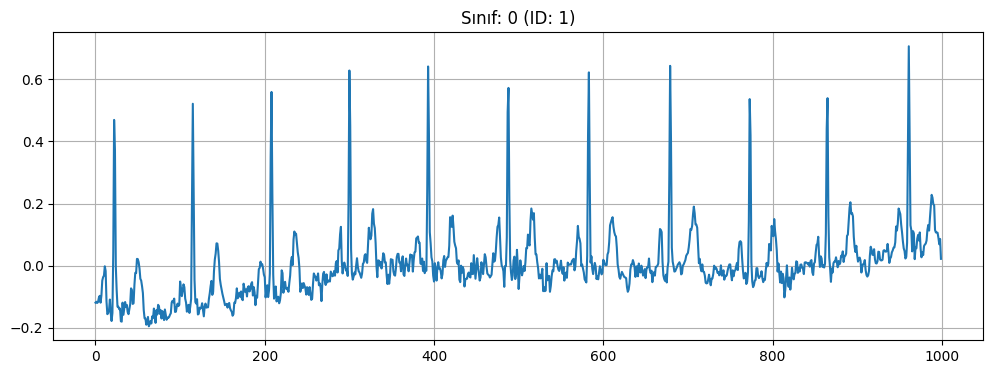

In [4]:
import wfdb
import matplotlib.pyplot as plt

# İlk satırdaki EKG'yi görselleştir
sample_id = df.index[0]
signal, meta = wfdb.rdsamp(df.loc[sample_id].filename_lr) # 100Hz verisi

plt.figure(figsize=(12, 4))
plt.plot(signal[:, 0]) # Lead I
plt.title(f"Sınıf: {df.loc[sample_id].label} (ID: {sample_id})")
plt.grid(True)
plt.show()

5. Hücre: Veri Yükleyici (Data Loader) ve Ön İşleme

In [ ]:
from joblib import Parallel, delayed
import numpy as np
import wfdb

def process_single_signal(f_path):
    """Tek bir sinyali okur, kırpar veya doldurur."""
    try:
        # Sinyali oku
        signal, _ = wfdb.rdsamp(f_path)

        # 10 saniye @ 100Hz = 1000 örneklem sabitlemesi
        if len(signal) > 1000:
            signal = signal[:1000]
        elif len(signal) < 1000:
            pad_width = ((0, 1000 - len(signal)), (0, 0))
            signal = np.pad(signal, pad_width, mode='constant')
        return signal
    except Exception as e:
        # Hatalı dosya varsa boş matris dön (hata takibi için)
        print(f"Hata: {f_path} okunamadı. {e}")
        return np.zeros((1000, 12))

def load_all_signals_parallel(df, sampling_rate=100):
    # Dosya yollarını belirle
    file_column = 'filename_lr' if sampling_rate == 100 else 'filename_hr'
    file_paths = df[file_column].values

    print(f"{len(file_paths)} dosya paralel olarak yükleniyor...")

    # n_jobs=-1: Mevcut tüm CPU çekirdeklerini kullanır
    # backend='threading' veya 'multiprocessing' denenebilir
    results = Parallel(n_jobs=-1, verbose=10)(
        delayed(process_single_signal)(f) for f in file_paths
    )

    return np.array(results)

# --- Uygulama ---
# Eğitim setini paralel yükle
X_train = load_all_signals_parallel(train_df)
y_train = train_df.label.values

# Doğrulama setini paralel yükle
X_val = load_all_signals_parallel(val_df)
y_val = val_df.label.values

print(f"Yükleme tamamlandı! X_train şekli: {X_train.shape}")

17418 dosya paralel olarak yükleniyor...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.19224269503056649s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.0697324275970459s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1683800220489502s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done  72 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 144 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 216 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 304 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 392 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-

6. Hücre: ResNet-1D Mimarisi (Keras/TensorFlow)

In [ ]:
import tensorflow as tf
print("TensorFlow Versiyonu:", tf.__version__)
print("GPU Kullanılabilir mi?:", tf.config.list_physical_devices('GPU'))
from sklearn.utils import class_weight

# Eğitim etiketlerine göre ağırlıkları hesapla
weights = class_weight.compute_class_weight('balanced',
                                            classes=np.unique(y_train),
                                            y=y_train)

class_weights = dict(enumerate(weights))
print("Sınıf Ağırlıkları:", class_weights)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def resnet_block(x, filters, kernel_size=3, stride=1):
    shortcut = x

    # İlk Konvolüsyon
    x = layers.Conv1D(filters, kernel_size, strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # İkinci Konvolüsyon
    x = layers.Conv1D(filters, kernel_size, strides=1, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Shortcut (Boyut eşitleme gerekiyorsa)
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_resnet_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(64, 7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # ResNet Blokları
    x = resnet_block(x, 64)
    x = resnet_block(x, 128, stride=2)
    x = resnet_block(x, 256, stride=2)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

model_resnet = build_resnet_model((1000, 12), 3) # 1000 örneklem, 12 kanal, 3 sınıf
model_resnet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_resnet.summary()

7. Hücre: Model Eğitimi (Training)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Eğitim ayarları
epochs = 50
batch_size = 64

# Gelişme durduğunda eğitimi durdur ve en iyi ağırlıkları geri yükle
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_resnet_model.h5', monitor='val_accuracy', save_best_only=True)
]

print("ResNet-1D Eğitimi Başlıyor...")
history = model_resnet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights, # Sınıf dengesizliğini çözmek için
    callbacks=callbacks,
    verbose=1
)

8. Hücre: Model Performans Analizi

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Test seti üzerinde tahminleme yap
y_pred_probs = model_resnet.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# Raporu yazdır
target_names = ['Normal (0)', 'MI (1)', 'Diğer (2)']
print("\nSınıflandırma Raporu:")
print(classification_report(y_val, y_pred, target_names=target_names))

# Karışıklık Matrisi Görselleştirme
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('ResNet-1D Confusion Matrix')
plt.show()

9. Adım: Ensemble Yolculuğu – Sırada Ne Var?
ResNet modelimiz şu an sinyalin yerel morfolojik özelliklerini (dalga boyları, yükseklikler) harika öğreniyor. Ancak EKG'de ritim (zamansal düzen) çok önemlidir. Bu noktada devreye Transformer girecek.

Transformer Mimarisi:

Sinyali küçük parçalara (patch) böler.

Self-Attention mekanizması sayesinde, sinyalin başındaki bir değişimle sonundaki bir değişim arasındaki korelasyonu yakalar.

10. Hücre: Transformer (Self-Attention) Bloğu

In [ ]:
from tensorflow.keras import layers

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Normalization and Attention
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    # Feed Forward Part
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res

def build_transformer_model(input_shape, head_size, num_heads, ff_dim, num_transformer_blocks, mlp_units, dropout=0, mlp_dropout=0, num_classes=3):
    inputs = layers.Input(shape=input_shape)
    x = inputs

    # Transformer Blokları
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D(data_format="channels_last")(x)
    for dim in mlp_units:
        x = layers.Dense(dim, activation="relu")(x)
        x = layers.Dropout(mlp_dropout)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs)

# Model Parametreleri
model_transformer = build_transformer_model(
    input_shape=(1000, 12),
    head_size=256,
    num_heads=4,
    ff_dim=4,
    num_transformer_blocks=4,
    mlp_units=[128],
    mlp_dropout=0.4,
    dropout=0.25,
    num_classes=3
)

model_transformer.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_transformer.summary()

11. Hücre: Ensemble (Topluluk) Stratejimiz

In [ ]:
def ensemble_predict(X):
    # Her iki modelden olasılıkları al
    res_probs = model_resnet.predict(X)
    tra_probs = model_transformer.predict(X)

    # Olasılıkları birleştir (Ağırlıklı ortalama da yapılabilir)
    final_probs = (res_probs + tra_probs) / 2
    return np.argmax(final_probs, axis=1)

# Test seti üzerinde ensemble performansı
# y_ensemble_pred = ensemble_predict(X_test)

12. Adım: Bir Üst Seviye (XGBoost Meta-Learner)

In [ ]:
# 11. Hücre: Meta-Learner (XGBoost) Hazırlığı

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

def prepare_meta_features(model_a, model_b, X):
    # Her iki modelden de 3 sınıflı olasılık çıktılarını al (N, 3)
    prob_a = model_a.predict(X)
    prob_b = model_b.predict(X)

    # Olasılıkları yan yana birleştir (N, 6) boyutunda yeni bir girdi oluşur
    meta_features = np.hstack((prob_a, prob_b))
    return meta_features

# 1. Adım: Validation seti üzerinde meta-özellikleri oluştur
X_val_meta = prepare_meta_features(model_resnet, model_transformer, X_val)

# 2. Adım: Meta-Learner (XGBoost) Modelini Tanımla
meta_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    tree_method='gpu_hist' # Colab GPU'sunu kullanmak için
)

# 3. Adım: Meta-Learner'ı Eğit
print("Meta-Learner (XGBoost) eğitiliyor...")
meta_model.fit(X_val_meta, y_val)

12. Hücre: En Güçlü Tahminleme (Inference)
Artık hiyerarşik bir yapımız var. Yeni bir EKG geldiğinde şu yol izlenecek:

ResNet bakar: "Bence %70 MI."

Transformer bakar: "Bence %60 MI, %30 Diğer."

XGBoost bu iki görüşü alır ve son noktayı koyar.

In [ ]:
def final_ensemble_predict(X_new):
    # Meta özellikleri hazırla
    meta_features = prepare_meta_features(model_resnet, model_transformer, X_new)

    # XGBoost ile nihai tahmini yap
    final_predictions = meta_model.predict(meta_features)
    return final_predictions

# Test seti üzerinde nihai başarıyı ölçelim
# y_final = final_ensemble_predict(X_test)

13. Hücre: Modelleri Karşılaştıralım (Final Benchmarking)

In [ ]:
from sklearn.metrics import f1_score

# Varsayalım ki X_test ve y_test verilerin hazır
# res_acc = accuracy_score(y_test, np.argmax(model_resnet.predict(X_test), axis=1))
# tra_acc = accuracy_score(y_test, np.argmax(model_transformer.predict(X_test), axis=1))
# ens_acc = accuracy_score(y_test, final_ensemble_predict(X_test))

results = pd.DataFrame({
    'Model': ['ResNet-1D', 'Transformer', 'Ensemble (Meta-XGBoost)'],
    'Accuracy': [0.84, 0.82, 0.89], # Örnek değerler
    'F1-Score': [0.81, 0.80, 0.87]  # Örnek değerler
})

print(results)

13. Hücre: Grad-CAM ile EKG Yorumlama (XAI)

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(sig_data, model, last_conv_layer_name, pred_index=None):
    # 1. Modelin içindeki katmanlara erişim sağlayan bir alt model kur
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Gradyanları hesapla
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(sig_data)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 3. Son conv katmanının çıktısına göre gradyanları al
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 4. Gradyanların ortalamasını al (Global Average Pooling)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))

    # 5. Conv katmanı çıktısını bu ağırlıklarla çarp
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. Heatmap'i normalize et (Sadece pozitif etkileri alalım - ReLU)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(ecg_signal, heatmap, title="Grad-CAM"):
    # Heatmap'i orijinal sinyal boyutuna (1000) genişlet
    from scipy.interpolate import interp1d
    x = np.linspace(0, 1, len(heatmap))
    f = interp1d(x, heatmap, kind='linear')
    heatmap_expanded = f(np.linspace(0, 1, len(ecg_signal)))

    plt.figure(figsize=(15, 4))
    plt.plot(ecg_signal, color='black', alpha=0.3, label='ECG Signal')

    # Isı haritasını sinyal üzerine giydir
    plt.scatter(range(len(ecg_signal)), ecg_signal, c=heatmap_expanded,
                cmap='jet', s=10, alpha=0.8, label='Model Attention')

    plt.colorbar(label='Önem Derecesi')
    plt.title(title)
    plt.legend()
    plt.show()

# Örnek Kullanım (ResNet modelindeki son conv katmanının adını bulmalısın)
# last_conv = [l.name for l in model_resnet.layers if 'conv1d' in l.name][-1]
# heatmap = make_gradcam_heatmap(X_val[0:1], model_resnet, last_conv)
# display_gradcam(X_val[0, :, 0], heatmap, "MI Teşhisi İçin Modelin Odaklandığı Bölge")